This notebook is part of the $\omega radlib$ documentation: https://docs.wradlib.org.

Copyright (c) $\omega radlib$ developers.
Distributed under the MIT License. See LICENSE.txt for more info.

# Production of a maximum reflectivity composite

In [1]:
import os
import numpy as np
import wradlib
import xarray
import xradar
import matplotlib.pyplot as plt

Read volume reflectivity measurements from the three belgian radars

In [2]:
from wradlib_data import DATASETS

filenames = ["bejab.pvol.hdf", "bewid.pvol.hdf", "behel.pvol.hdf"]
paths = [DATASETS.fetch(f"hdf5/{f}") for f in filenames]
volumes = [xradar.io.backends.odim.open_odim_datatree(p) for p in paths]

C:\Users\egoud\wradlib\.venv\Lib\site-packages\xradar\io\backends\common.py:286: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  subgroup = xr.merge([ds[extract_vars] for ds in ls_ds])
C:\Users\egoud\wradlib\.venv\Lib\site-packages\xradar\io\backends\common.py:286: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  subgroup = xr.merge([ds[ex

Define a raster dataset with a window including the 3 radars, a pixel size of 1km and the standard European projection.

In [3]:
crs = 3035
bounds = [3614000, 2783000, 4200000, 3338000]
resolution = 1000
raster1 = wradlib.georef.create_raster_xarray(
    crs=crs,
    bounds=bounds,
    resolution=resolution,
)

Define a geographic raster dataset with a window including the 3 radars, and an approximate pixel size of 1km. 

In [4]:
crs = 3035
bounds = [0, 48, 9, 53]
resolution = 1000
raster2 = wradlib.georef.create_raster_geographic(
    bounds=bounds, resolution=resolution, resolution_in_meters=True
)

Combine lowest radar sweep into a raster image for each radar

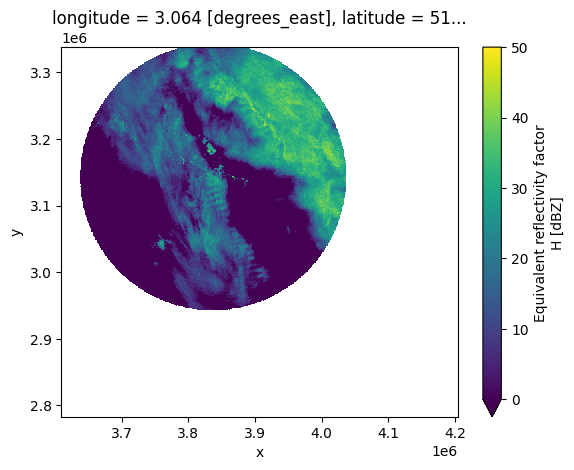

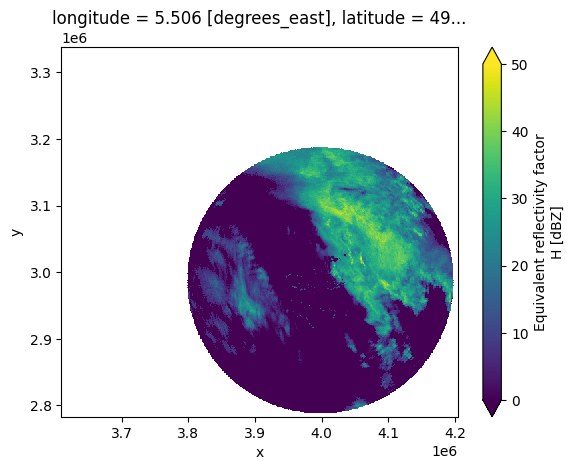

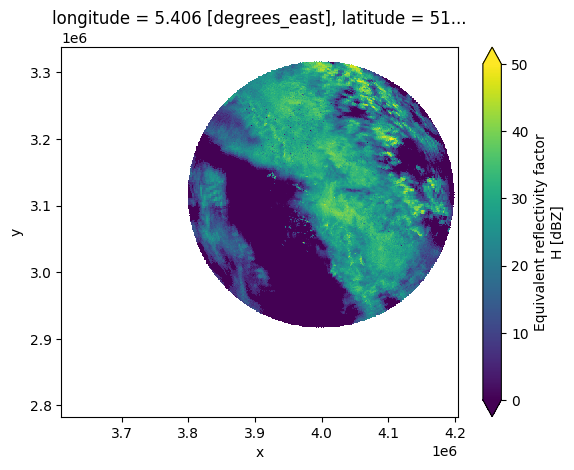

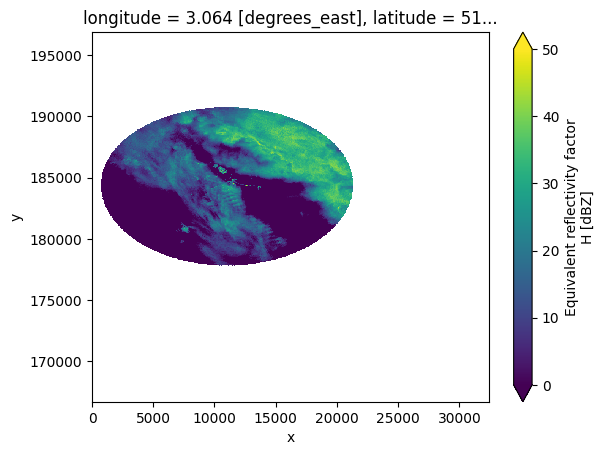

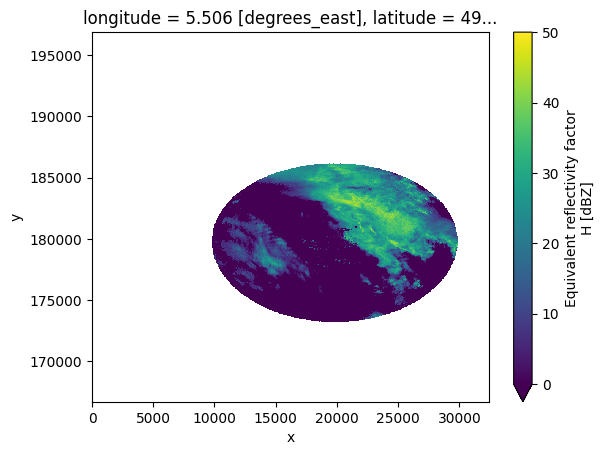

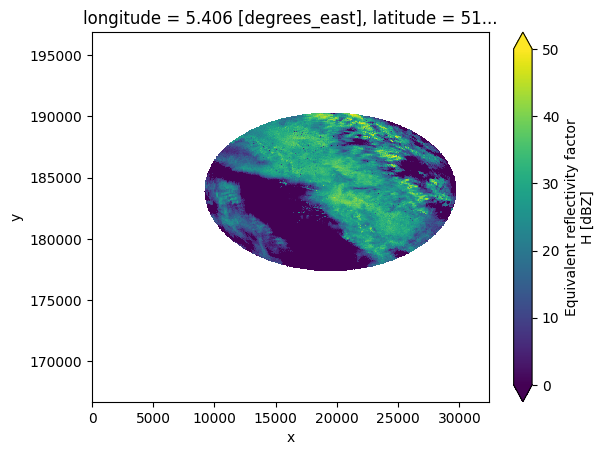

In [7]:
for raster in [raster1, raster2]:
    metadata = xradar.model.required_sweep_metadata_vars
    rasters = []
    for volume in volumes:
        sweep = volume["sweep_0"].to_dataset()
        sweep = sweep[["DBZH"] + list(metadata)]
        sweep = sweep.sel(range=slice(0, 200e3))
        raster_sweep = wradlib.comp.sweep_to_raster(sweep=sweep, raster=raster)
        rasters.append(raster_sweep)

    for raster in rasters:
        raster["DBZH"].plot(vmin=0, vmax=50)
        plt.axis("equal")
        plt.show()

Take the maximum value from the 3 rasters

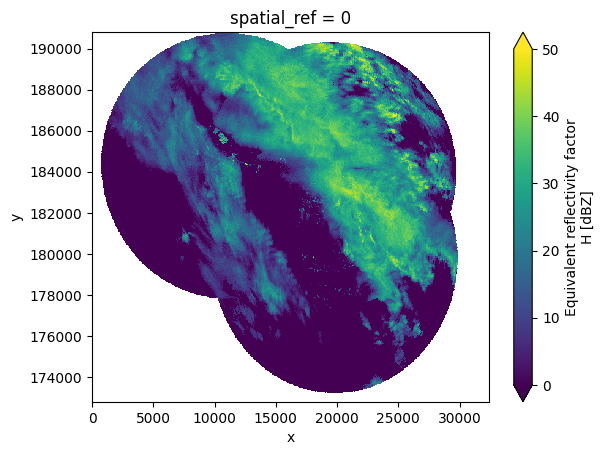

In [10]:
rasters_concat = xarray.concat(rasters, dim="sweep")
comp = rasters_concat.max(dim="sweep", keep_attrs=True)
with open("comp.nc", "wb") as f:
    comp.to_netcdf(f)
comp["DBZH"].plot(vmin=0, vmax=50)